In [38]:
import pandas as pd
from pathlib import Path
path = Path("Data")
path.mkdir(exist_ok=True)
df = pd.read_csv("cleaned_data.csv")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
df.head()


,IndexYear,IndexMonth,IndexDayOfWeek,IndexDepartmentKey,IndexDepartmentName,IndexDepartmentType,IndexDepartmentSpecialty,IndexDepartmentCity,IndexDepartmentCounty,IndexDepartmentPostalCode,IndexAdmissionSource,IndexAdmissionType,IndexVisitType,IndexVisitTypeDescription,FirstRace,MaritalStatus,MyChartStatus,OmbEthnicity,OmbRace,PatientBirthYearBin,SexAssignedAtBirth,SexualOrientation,SmokingStatus,VitalStatus,ClinicianTitle,PrimaryDepartment,PrimarySpecialty,OfficeCity,OfficePostalCode,isBroken,DistanceMilesToIndexDept
0,2022,1,1,349,901 INTERNAL MED,Missing,Internal Medicine,Topeka,SHAWNEE,66606,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Married,Activated,Not Hispanic or Latino,White,1960.0,Male,Straight,Former,Alive,Missing,Missing,Missing,Missing,Missing,0,4.206557
1,2022,1,1,358,901 FAMILY PRACTICE,Missing,Family Medicine,Topeka,SHAWNEE,66606,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,1950.0,Missing,Missing,Never,Alive,Missing,Missing,Missing,Missing,Missing,1,4.693631
2,2022,1,1,10282,ASBURY CLINIC,Missing,Primary Care,TOPEKA,SHAWNEE,66614-4466,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Divorced,Activated,Not Hispanic or Latino,White,1970.0,Female,Straight,Never,Alive,Missing,Missing,Missing,Missing,Missing,0,4.693631
3,2022,1,1,341,823 WOUNDCARE,Missing,Wound Care,Topeka,SHAWNEE,66606,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Divorced,Activated,Not Hispanic or Latino,White,1950.0,Male,Straight,Former,Alive,APRN,823 WOUNDCARE,Nurse Practitioner,TOPEKA,66606,0,2.565065
4,2022,1,1,299,6TH FRAZIER ENDOCRINOLOGY,Missing,Endocrinology,Topeka,SHAWNEE,66606,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,1955.0,Male,Straight,Never,Alive,Missing,Missing,Missing,Missing,Missing,0,4.693631


In [39]:
Y = df[["isBroken"]]
df = df.drop(columns = ["IndexDepartmentKey","IndexDepartmentPostalCode",
             "PrimaryDepartment","OfficeCity","OfficePostalCode","isBroken"])
df.columns


Index(['IndexYear', 'IndexMonth', 'IndexDayOfWeek', 'IndexDepartmentName',
       'IndexDepartmentType', 'IndexDepartmentSpecialty',
       'IndexDepartmentCity', 'IndexDepartmentCounty', 'IndexAdmissionSource',
       'IndexAdmissionType', 'IndexVisitType', 'IndexVisitTypeDescription',
       'FirstRace', 'MaritalStatus', 'MyChartStatus', 'OmbEthnicity',
       'OmbRace', 'PatientBirthYearBin', 'SexAssignedAtBirth',
       'SexualOrientation', 'SmokingStatus', 'VitalStatus', 'ClinicianTitle',
       'PrimarySpecialty', 'DistanceMilesToIndexDept'],
      dtype='object')

In [40]:
Y["isBroken"].value_counts(normalize=True)

isBroken
1    0.537455
0    0.462545
Name: proportion, dtype: float64

In [41]:
X = df.copy()
X

,IndexYear,IndexMonth,IndexDayOfWeek,IndexDepartmentName,IndexDepartmentType,IndexDepartmentSpecialty,IndexDepartmentCity,IndexDepartmentCounty,IndexAdmissionSource,IndexAdmissionType,IndexVisitType,IndexVisitTypeDescription,FirstRace,MaritalStatus,MyChartStatus,OmbEthnicity,OmbRace,PatientBirthYearBin,SexAssignedAtBirth,SexualOrientation,SmokingStatus,VitalStatus,ClinicianTitle,PrimarySpecialty,DistanceMilesToIndexDept
0,2022,1,1,901 INTERNAL MED,Missing,Internal Medicine,Topeka,SHAWNEE,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Married,Activated,Not Hispanic or Latino,White,1960.0,Male,Straight,Former,Alive,Missing,Missing,4.206557
1,2022,1,1,901 FAMILY PRACTICE,Missing,Family Medicine,Topeka,SHAWNEE,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,1950.0,Missing,Missing,Never,Alive,Missing,Missing,4.693631
2,2022,1,1,ASBURY CLINIC,Missing,Primary Care,TOPEKA,SHAWNEE,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Divorced,Activated,Not Hispanic or Latino,White,1970.0,Female,Straight,Never,Alive,Missing,Missing,4.693631
3,2022,1,1,823 WOUNDCARE,Missing,Wound Care,Topeka,SHAWNEE,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Divorced,Activated,Not Hispanic or Latino,White,1950.0,Male,Straight,Former,Alive,APRN,Nurse Practitioner,2.565065
4,2022,1,1,6TH FRAZIER ENDOCRINOLOGY,Missing,Endocrinology,Topeka,SHAWNEE,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,1955.0,Male,Straight,Never,Alive,Missing,Missing,4.693631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18871,2025,7,4,MHK PRIMARY CARE,Missing,Primary Care,MANHATTAN,RILEY,Missing,Missing,OFFICE VISIT,Clinic Visit- In Person,White or Caucasian,Married,Activated,Not Hispanic or Latino,White,1960.0,Missing,Missing,Every Day,Alive,Missing,Missing,22.390600
18872,2025,7,4,6TH FRAZIER ENDOCRINOLOGY,Missing,Endocrinology,Topeka,SHAWNEE,Missing,Missing,HOSP/ER FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,1995.0,Missing,Missing,Former,Alive,Missing,Missing,10.256541
18873,2025,7,4,6TH FRAZIER ENDOCRINOLOGY,Missing,Endocrinology,Topeka,SHAWNEE,Missing,Missing,CONSULT,Clinic Visits- In person,White or Caucasian,Married,Activated,Not Hispanic or Latino,White,1940.0,Missing,Missing,Never,Alive,Missing,Missing,9.200649
18874,2025,7,4,ASBURY CLINIC,Missing,Primary Care,TOPEKA,SHAWNEE,Missing,Missing,FOLLOW UP,Clinic Visits- In Person,White or Caucasian,Married,Activated,Not Hispanic or Latino,White,1980.0,Missing,Missing,Never,Alive,Missing,Missing,4.693631


In [42]:
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# split features
num_cols = X.select_dtypes(include=["number"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combine
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18876 entries, 0 to 18875
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   IndexYear                  18876 non-null  int64  
 1   IndexMonth                 18876 non-null  int64  
 2   IndexDayOfWeek             18876 non-null  int64  
 3   IndexDepartmentName        18876 non-null  object 
 4   IndexDepartmentType        18876 non-null  object 
 5   IndexDepartmentSpecialty   18876 non-null  object 
 6   IndexDepartmentCity        18876 non-null  object 
 7   IndexDepartmentCounty      18876 non-null  object 
 8   IndexAdmissionSource       18876 non-null  object 
 9   IndexAdmissionType         18876 non-null  object 
 10  IndexVisitType             18876 non-null  object 
 11  IndexVisitTypeDescription  18876 non-null  object 
 12  FirstRace                  18876 non-null  object 
 13  MaritalStatus              18876 non-null  obj

In [44]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    print(f"{col} ({df[col].nunique()} unique)")
    print(df[col].value_counts().head(10))
    print("\n")

IndexDepartmentName (104 unique)
IndexDepartmentName
6TH FRAZIER ENDOCRINOLOGY    4919
901 INTERNAL MED             1594
ASBURY CLINIC                1355
NORTH FIELDING CLINIC        1188
EMPORIA INTERNAL MED         1128
MHK PRIMARY CARE             1005
901 FAMILY PRACTICE           758
823 FAMILY PRACTICE           665
FHC FAMILY PRACTICE           628
EMPORIA FAMILY PRACTICE       613
Name: count, dtype: int64


IndexDepartmentType (4 unique)
IndexDepartmentType
Missing    18649
OR            86
Normal        83
HOD           58
Name: count, dtype: int64


IndexDepartmentSpecialty (34 unique)
IndexDepartmentSpecialty
Family Medicine          5913
Endocrinology            5254
Internal Medicine        3687
Primary Care             2374
Wound Care                483
Ophthalmology             256
Nephrology                191
Missing                    93
Pre-Admission Testing      86
Neurology                  80
Name: count, dtype: int64


IndexDepartmentCity (14 unique)
IndexDepar

In [45]:
X = X.drop(columns = ["PrimarySpecialty","ClinicianTitle","SexualOrientation","SexAssignedAtBirth"
                      ,"IndexAdmissionType","IndexAdmissionSource","IndexDepartmentType"])

In [46]:
X['IndexDepartmentCity'] = X['IndexDepartmentCity'].str.upper()

def clean_visit_type(x):
    if pd.isna(x):
        return "unknown"
    x = x.lower().strip()

    if "clinic" in x and "virtual" in x:
        return "clinic_virtual"
    if "clinic" in x:
        return "clinic_in_person"
    if "lab" in x:
        return "lab"
    if "ultrasound" in x or "imaging" in x:
        return "imaging"
    if "procedure" in x:
        return "procedures"
    if "admission" in x:
        return "pre_admission"

    return "other"

df["IndexVisitTypeDescription"] = df["IndexVisitTypeDescription"].apply(clean_visit_type)


In [48]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    print(f"{col} ({df[col].nunique()} unique)")
    print(X[col].value_counts().head(10))
    print("\n")

IndexDepartmentName (104 unique)
IndexDepartmentName
6TH FRAZIER ENDOCRINOLOGY    4919
901 INTERNAL MED             1594
ASBURY CLINIC                1355
NORTH FIELDING CLINIC        1188
EMPORIA INTERNAL MED         1128
MHK PRIMARY CARE             1005
901 FAMILY PRACTICE           758
823 FAMILY PRACTICE           665
FHC FAMILY PRACTICE           628
EMPORIA FAMILY PRACTICE       613
Name: count, dtype: int64


IndexDepartmentSpecialty (34 unique)
IndexDepartmentSpecialty
Family Medicine          5913
Endocrinology            5254
Internal Medicine        3687
Primary Care             2374
Wound Care                483
Ophthalmology             256
Nephrology                191
Missing                    93
Pre-Admission Testing      86
Neurology                  80
Name: count, dtype: int64


IndexDepartmentCity (14 unique)
IndexDepartmentCity
TOPEKA           13343
EMPORIA           1813
MANHATTAN         1142
JUNCTION CITY      974
OSAGE CITY         392
WAMEGO             374

<Axes: >

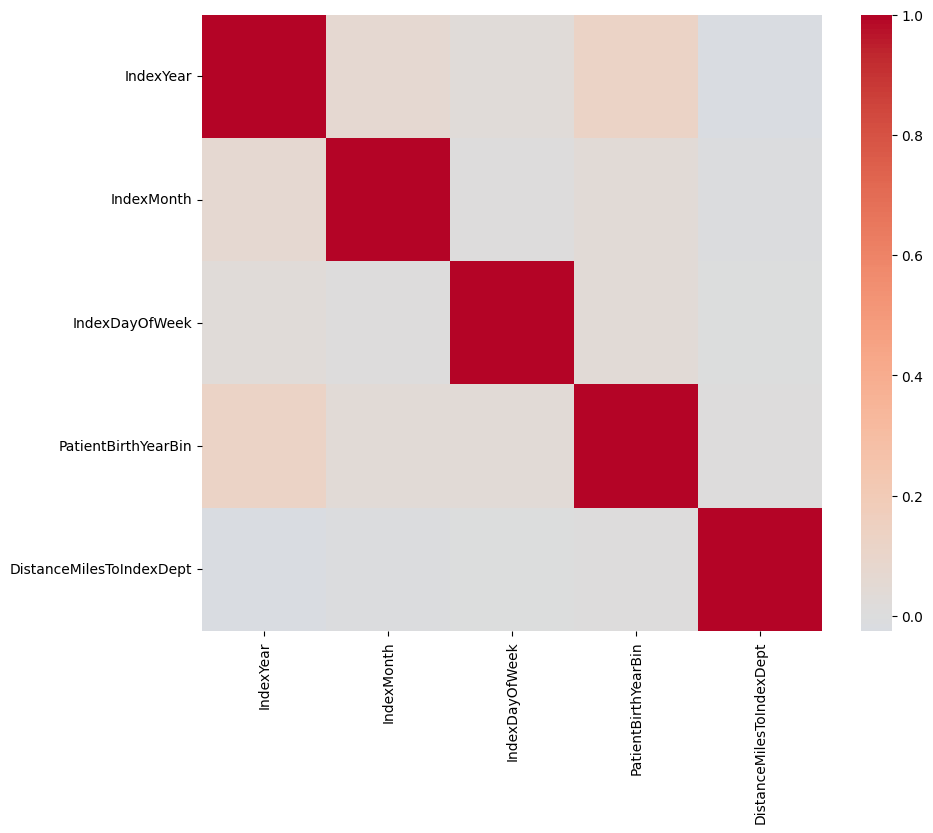

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)

c:\Users\dilra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


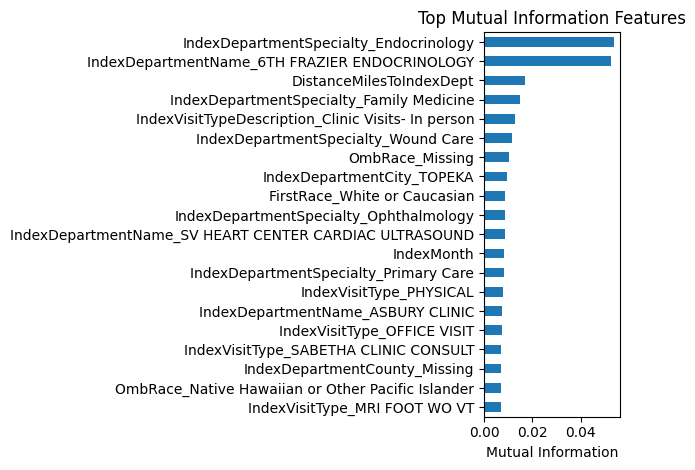

In [50]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd



# You MUST encode categorical variables first
X_encoded = pd.get_dummies(X, drop_first=True)

mi = mutual_info_classif(X_encoded, Y, random_state=42)

mi_series = pd.Series(mi, index=X_encoded.columns).sort_values(ascending=False)
import matplotlib.pyplot as plt

top_n = 20

mi_series.head(top_n).sort_values().plot(kind="barh")
plt.title("Top Mutual Information Features")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

Index(['IndexYear', 'IndexMonth', 'IndexDayOfWeek', 'PatientBirthYearBin',
       'DistanceMilesToIndexDept',
       'IndexDepartmentName_6TH FRAZIER ENDOCRINOLOGY',
       'IndexDepartmentName_6TH FRAZIER LAB',
       'IndexDepartmentName_6TH ST MIDTOWN EXPRESS',
       'IndexDepartmentName_7 NORTH', 'IndexDepartmentName_823 BARIATRICS',
       ...
       'OmbRace_White', 'SmokingStatus_Former', 'SmokingStatus_Heavy Smoker',
       'SmokingStatus_Light Smoker', 'SmokingStatus_Missing',
       'SmokingStatus_Never', 'SmokingStatus_Never Assessed',
       'SmokingStatus_Passive Smoke Exposure - Never Smoker',
       'SmokingStatus_Some Days', 'VitalStatus_Deceased'],
      dtype='object', length=348)